In [1]:

# Week 2: Supervised Machine Learning Models
# Yuvaintern AI Pioneers Internship

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("All required libraries imported successfully!")


All required libraries imported successfully!


In [2]:

# STEP 3: Load and Explore the Datasets

from sklearn.datasets import load_breast_cancer, load_diabetes

# Load classification dataset
cancer = load_breast_cancer(as_frame=True)
classification_df = cancer.frame

# Load regression dataset
diabetes = load_diabetes(as_frame=True)
regression_df = diabetes.frame

print("CLASSIFICATION DATASET")
print("Shape:", classification_df.shape)
print("\nFirst 5 rows:")
display(classification_df.head())

print("\nMissing values:", classification_df.isnull().sum().sum())
print("\nTarget classes:")
print(classification_df["target"].value_counts().sort_index())

print("\n" + "=" * 50)

print("\nREGRESSION DATASET")
print("Shape:", regression_df.shape)
print("\nFirst 5 rows:")
display(regression_df.head())

print("\nMissing values:", regression_df.isnull().sum().sum())
print("\nTarget summary:")
print(regression_df["target"].describe())


CLASSIFICATION DATASET
Shape: (569, 31)

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Missing values: 0

Target classes:
target
0    212
1    357
Name: count, dtype: int64


REGRESSION DATASET
Shape: (442, 11)

First 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0



Missing values: 0

Target summary:
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


In [3]:

# STEP 4: Train and Evaluate Machine Learning Models

# Split the regression dataset
X_reg = regression_df.drop(columns=["target"])
y_reg = regression_df["target"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Train regression models
regression_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100, random_state=42
    )
}

regression_results = []

for name, model in regression_models.items():
    model.fit(X_reg_train, y_reg_train)
    predictions = model.predict(X_reg_test)

    regression_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_reg_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_reg_test, predictions)),
        "R2 Score": r2_score(y_reg_test, predictions)
    })

regression_results_df = pd.DataFrame(regression_results)

print("REGRESSION MODEL RESULTS")
display(regression_results_df.round(3))


# Split the classification dataset
X_clf = classification_df.drop(columns=["target"])
y_clf = classification_df["target"]

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Train classification models
classification_models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=5000)
    ),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
    "K-Nearest Neighbors": make_pipeline(
        StandardScaler(), KNeighborsClassifier(n_neighbors=5)
    )
}

classification_results = []
classification_predictions = {}

for name, model in classification_models.items():
    model.fit(X_clf_train, y_clf_train)
    predictions = model.predict(X_clf_test)
    classification_predictions[name] = predictions

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_clf_test, predictions),
        "Precision": precision_score(
            y_clf_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_clf_test, predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_clf_test, predictions, zero_division=0
        )
    })

classification_results_df = pd.DataFrame(classification_results)

print("\nCLASSIFICATION MODEL RESULTS")
display(classification_results_df.round(3))

print("\nTraining and evaluation completed successfully!")


REGRESSION MODEL RESULTS


,Model,MAE,RMSE,R2 Score
0,Linear Regression,42.794,53.853,0.453
1,Random Forest Regressor,44.053,54.332,0.443



CLASSIFICATION MODEL RESULTS


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982,0.986,0.986,0.986
1,Decision Tree,0.912,0.956,0.903,0.929
2,Random Forest,0.956,0.959,0.972,0.966
3,K-Nearest Neighbors,0.956,0.959,0.972,0.966



Training and evaluation completed successfully!


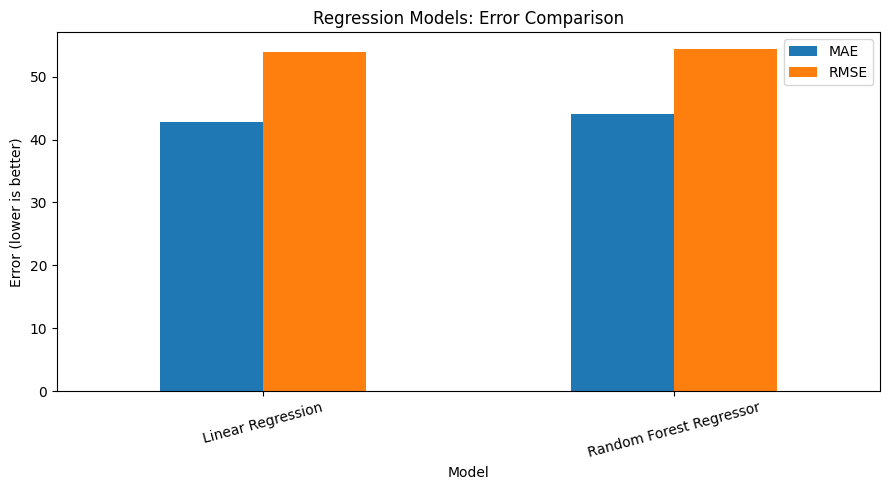

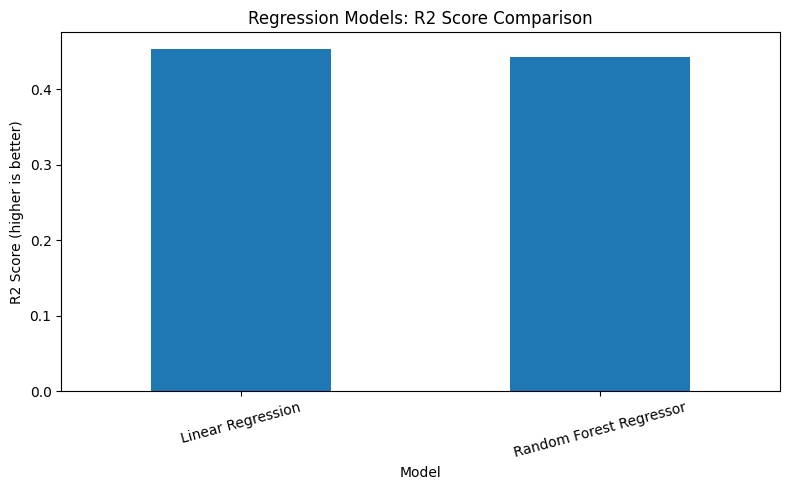

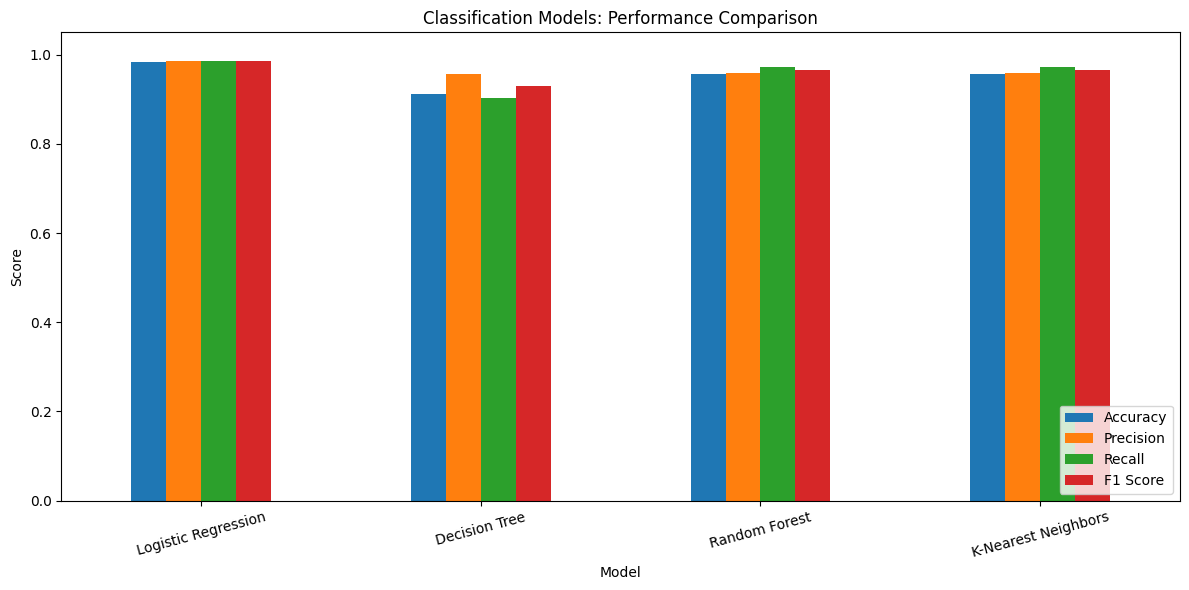

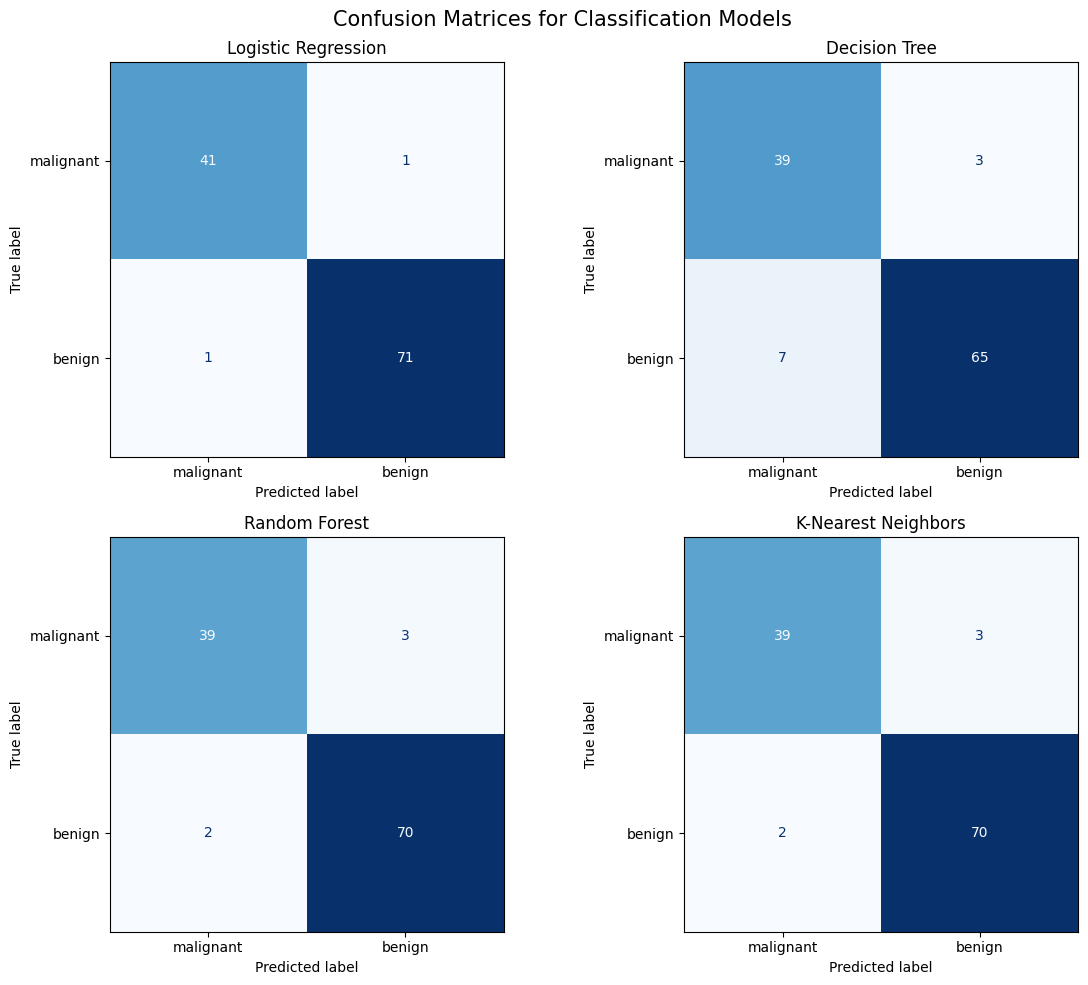

All visualization charts generated successfully!


In [4]:

# STEP 5: Visualize Model Performance

# Chart 1: Regression model comparison
regression_results_df.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar", figsize=(9, 5)
)

plt.title("Regression Models: Error Comparison")
plt.ylabel("Error (lower is better)")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()


# Chart 2: Regression R2 scores
regression_results_df.set_index("Model")["R2 Score"].plot(
    kind="bar", figsize=(8, 5)
)

plt.title("Regression Models: R2 Score Comparison")
plt.ylabel("R2 Score (higher is better)")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# Chart 3: Classification model comparison
classification_results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(kind="bar", figsize=(12, 6))

plt.title("Classification Models: Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# Chart 4: Confusion matrices for all classification models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, predictions) in zip(
    axes.ravel(), classification_predictions.items()
):
    ConfusionMatrixDisplay.from_predictions(
        y_clf_test,
        predictions,
        display_labels=cancer.target_names,
        cmap="Blues",
        ax=ax,
        colorbar=False
    )
    ax.set_title(name)

plt.suptitle("Confusion Matrices for Classification Models", fontsize=15)
plt.tight_layout()
plt.show()

print("All visualization charts generated successfully!")


In [5]:

# STEP 6A: Worked Examples of Model Predictions

# Regression: compare actual and predicted diabetes progression
best_regression_name = regression_results_df.sort_values(
    "RMSE"
).iloc[0]["Model"]

best_regression_model = regression_models[best_regression_name]
regression_predictions = best_regression_model.predict(X_reg_test)

regression_example = pd.DataFrame({
    "Actual Value": y_reg_test.iloc[:10].values,
    "Predicted Value": regression_predictions[:10]
})

print("REGRESSION PREDICTION EXAMPLES")
print("Model selected by lowest RMSE:", best_regression_name)
display(regression_example.round(2))


# Classification: show actual and predicted cancer classes
best_classification_name = classification_results_df.sort_values(
    "F1 Score", ascending=False
).iloc[0]["Model"]

classification_example = pd.DataFrame({
    "Actual Class": cancer.target_names[
        y_clf_test.iloc[:10].values
    ],
    "Predicted Class": cancer.target_names[
        classification_predictions[best_classification_name][:10]
    ]
})

print("\nCLASSIFICATION PREDICTION EXAMPLES")
print("Model selected by highest F1 score:", best_classification_name)
display(classification_example)


REGRESSION PREDICTION EXAMPLES
Model selected by lowest RMSE: Linear Regression


,Actual Value,Predicted Value
0,219.0,139.55
1,70.0,179.52
2,202.0,134.04
3,230.0,291.42
4,111.0,123.79
5,84.0,92.17
6,242.0,258.23
7,272.0,181.34
8,94.0,90.22
9,96.0,108.63



CLASSIFICATION PREDICTION EXAMPLES
Model selected by highest F1 score: Logistic Regression


,Actual Class,Predicted Class
0,malignant,malignant
1,benign,benign
2,malignant,malignant
3,benign,benign
4,malignant,malignant
5,benign,benign
6,benign,benign
7,malignant,malignant
8,malignant,malignant
9,malignant,malignant


In [6]:

# STEP 6B: Automatic Model Performance Analysis

best_reg = regression_results_df.loc[
    regression_results_df["RMSE"].idxmin()
]

best_clf = classification_results_df.loc[
    classification_results_df["F1 Score"].idxmax()
]

print("PROJECT FINDINGS")
print("-" * 50)

print(
    f"1. Best regression model by RMSE: {best_reg['Model']} "
    f"(RMSE = {best_reg['RMSE']:.3f}, "
    f"R2 = {best_reg['R2 Score']:.3f})."
)

print(
    f"2. Best classification model by F1 score: "
    f"{best_clf['Model']} "
    f"(F1 = {best_clf['F1 Score']:.3f}, "
    f"Accuracy = {best_clf['Accuracy']:.3f})."
)

print(
    "3. Regression metrics measure prediction error and "
    "explained variation."
)

print(
    "4. Classification metrics measure different aspects of "
    "class prediction performance."
)

print(
    "5. The results apply to this test split; performance may "
    "change with different data or splits."
)


PROJECT FINDINGS
--------------------------------------------------
1. Best regression model by RMSE: Linear Regression (RMSE = 53.853, R2 = 0.453).
2. Best classification model by F1 score: Logistic Regression (F1 = 0.986, Accuracy = 0.982).
3. Regression metrics measure prediction error and explained variation.
4. Classification metrics measure different aspects of class prediction performance.
5. The results apply to this test split; performance may change with different data or splits.


In [7]:

# STEP 7: Export Results, Charts, and Prediction Examples

import os
import zipfile
import matplotlib.pyplot as plt

output_dir = "ML_Project_Results"
os.makedirs(output_dir, exist_ok=True)

# Save evaluation tables
regression_results_df.to_csv(
    f"{output_dir}/regression_results.csv", index=False
)

classification_results_df.to_csv(
    f"{output_dir}/classification_results.csv", index=False
)

regression_example.to_csv(
    f"{output_dir}/regression_predictions.csv", index=False
)

classification_example.to_csv(
    f"{output_dir}/classification_predictions.csv", index=False
)

# Save all open figures as image files
for number in plt.get_fignums():
    fig = plt.figure(number)
    fig.savefig(
        f"{output_dir}/chart_{number}.png",
        dpi=200,
        bbox_inches="tight"
    )

# Create a ZIP file containing the results
zip_name = "ML_Project_Results.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zip_file:
    for filename in os.listdir(output_dir):
        zip_file.write(
            os.path.join(output_dir, filename),
            arcname=f"ML_Project_Results/{filename}"
        )

print("Export completed!")
print("Files included:")
for filename in sorted(os.listdir(output_dir)):
    print("-", filename)

print("\nZIP file created:", zip_name)


Export completed!
Files included:
- classification_predictions.csv
- classification_results.csv
- regression_predictions.csv
- regression_results.csv

ZIP file created: ML_Project_Results.zip


In [8]:

from google.colab import files
files.download("ML_Project_Results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>